# Random variables

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2023, University of Chicago 

---

We will cover how to generate random variables according to a variety of distributions.

We will use a scientific library called Numpy, which provides high-performance libraries to deal with multi-dimensional arrays (which are like Python lists).

We will use Numpy to generate random variables according to some distribution.  See the docs at:  https://het.as.utexas.edu/HET/Software/Numpy/reference/routines.random.html


In [1]:
import numpy as np

### Uniform floating point random variables  

In [2]:
x = np.random.rand()
print(x)

0.4265891655689522


In [3]:
x = np.random.uniform(1,5)
print(x)

2.027179111540475


In [4]:
x = np.random.uniform(-1,1,size=5)
print(x)

[ 0.29573419  0.78661471  0.09582087 -0.11070991  0.20281309]


### Uniform integer random variables

In [5]:
x = np.random.randint(1,11,size=100) # 11 will NOT be included
print(x)

[ 9  4  5  3  4 10  4  7  9  1 10  6 10  4  8  8  8  9  8 10  7  2  2  1
  8  3  2  1  4  1  3  3  6  3  5  4  2  3 10  9  9  9  8  8  3  8  9  9
  8  2 10  9  9  3  1  2  4  6 10  4  5  9  4 10  2  6  6  7  6  7  8  6
  4  3  4  5  2  5 10  6  7  2  5  1  9  8  3  3  3  7  1  2  8  2  3  3
  2  5  6  2]


In [6]:
np.random.seed(12345)
y = np.random.uniform(1,101,size=2)
print(y)

[93.96160928 32.63755546]


### The useful `unique` method

In [7]:
arr = np.array([1,2,2,2,2,2,3,4,5,6,7,8,9])
np.unique(arr)

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

### Choose and Shuffle

In [8]:
lst = [1,2,3,4,5]
x = np.random.choice(lst)
print(x)

5


In [9]:
lst_shuffle = [1,2,3,4,5]
np.random.shuffle(lst_shuffle)
print(lst_shuffle)

[1, 5, 4, 3, 2]


### Normal Random Variables

In [10]:
x = np.random.normal(100,10)
print(x)

105.95091114182217


In [11]:
lst = np.random.normal(0,100,size=50)
print(lst)

[   4.18340299   80.0446696    -7.19216806 -104.30688774  -38.11557746
  -76.60782274 -157.74426735   48.81764724  118.03132571   12.06597967
   87.27391549  141.79596794 -100.97023729    8.276794     -9.22215916
  113.94706506  -87.25911302 -170.70046588  121.1992065    65.19972032
   96.89584514    0.80843873    2.45925917  -61.87246636 -134.5969146
  -14.43272205  191.00402987  180.8867289  -110.59407135   34.45327513
  155.30144804   54.78008773   25.64372314 -151.29172821  -87.81081892
   -1.72761692  -13.65942235  -73.01090176  139.82677407  -33.69220733
   -0.4680224   -76.02340945 -124.61125256   27.88455104  -47.32003836
 -174.21253242  -96.80822838  -70.96244838  115.49068188   69.07505761]


### Compute mean and standard dev from a list, and convert to integers, and truncate at 0

In [12]:
np.mean(lst)

np.float64(-2.5973581108405166)

In [13]:
np.std(lst)

np.float64(95.74721844319951)

### Truncate and Lower bounds 

In [14]:
lst_int = lst.astype(int)
print(lst_int)

[   4   80   -7 -104  -38  -76 -157   48  118   12   87  141 -100    8
   -9  113  -87 -170  121   65   96    0    2  -61 -134  -14  191  180
 -110   34  155   54   25 -151  -87   -1  -13  -73  139  -33    0  -76
 -124   27  -47 -174  -96  -70  115   69]


In [15]:
lst_clipped = lst.clip(0)
print(lst_clipped)

[  4.18340299  80.0446696    0.           0.           0.
   0.           0.          48.81764724 118.03132571  12.06597967
  87.27391549 141.79596794   0.           8.276794     0.
 113.94706506   0.           0.         121.1992065   65.19972032
  96.89584514   0.80843873   2.45925917   0.           0.
   0.         191.00402987 180.8867289    0.          34.45327513
 155.30144804  54.78008773  25.64372314   0.           0.
   0.           0.           0.         139.82677407   0.
   0.           0.           0.          27.88455104   0.
   0.           0.           0.         115.49068188  69.07505761]


### The exponential distribution is commonly used to simulate the time between random arrivals to a system

In [16]:
x = np.random.exponential(10,size=10000)

Text(0.5, 0, 'Data')

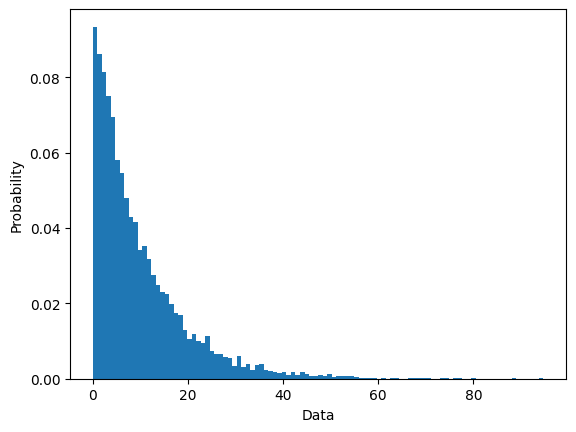

In [17]:
import matplotlib.pyplot as plt
plt.hist(x, density=True, bins=100)
plt.ylabel('Probability')
plt.xlabel('Data')

## A Challenge
Your intro probability class might have attempted to convince you that it only takes about 23 random birthdays to have a 50% chance of two being the same.

1) First generate 23 random birthdays ... and determine if any of them are the same?
2) Now, run the 23 random birthday experiment 1000 times, what proportion of the experiments resulted in at least one duplicated birthday?  


In [20]:
twenty_three_random_birthdays = np.random.randint(1,366,size=23)
print(twenty_three_random_birthdays)

[169 179 172 335 339 306 259  96 364 154 347 233 245 125 334 223  29 258
 274  33 129 124 125]


In [21]:
num_unique_birthdays = len(np.unique(twenty_three_random_birthdays))
print(num_unique_birthdays)

22


In [33]:
num_experiments = 1000
num_duplicates = 0

for i in range(num_experiments):
    twenty_three_random_birthdays = np.random.randint(1,366,size=23)
    num_unique_birthdays = len(np.unique(twenty_three_random_birthdays))
    if num_unique_birthdays != 23:
        num_duplicates += 1

print(f'The proportion of experiments with at least one duplicate birthday is {num_duplicates/num_experiments}')

The proportion of experiments with at least one duplicate birthday is 0.487
